<a href="https://colab.research.google.com/github/charfx/Detecteur-du-sujet-des-publications-d-actualite-via-NLP-and-DL-./blob/main/NLP_BC_news.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problématique

Le texte brut est une donnée non structurée que les modèles de Machine Learning ne peuvent pas exploiter directement.

Le défi principal consiste donc à :
- transformer le langage humain en représentation numérique ;
- apprendre les relations contextuelles entre les mots ;
- classifier automatiquement un article dans la bonne catégorie.

---

## Objectif du projet

L’objectif de ce projet est de construire un modèle Deep Learning capable de classifier automatiquement des articles BBC selon leur thème principal.

Pour cela, plusieurs étapes seront réalisées :
- préparation et structuration du dataset ;
- nettoyage du texte ;
- tokenization et padding ;
- transformation des mots en vecteurs numériques via Embedding ;
- apprentissage séquentiel avec un modèle Bidirectional LSTM ;
- évaluation et optimisation des performances.

---

## Dataset utilisé

Le projet utilise le dataset BBC News Dataset disponible sur Kaggle.

Le dataset contient des articles BBC classés en plusieurs catégories :
- business
- entertainment
- politics
- sport
- tech

Chaque article est stocké sous forme de fichier texte (`.txt`) dans un dossier représentant sa catégorie.


In [99]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Embedding, LSTM, Dense, Dropout,Bidirectional
from tensorflow.keras.callbacks import EarlyStopping


## 1. Extraction et lecture du dataset

Dans cette étape, nous allons parcourir les dossiers du dataset BBC.  
Chaque dossier représente une catégorie d’actualité, et chaque fichier `.txt` représente un article.  
L’objectif est de transformer cette structure de fichiers en un DataFrame contenant deux colonnes : `text` et `category`.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import zipfile
zip_path = "archive (1).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/bbc_dataset")

In [8]:
import os
os.listdir('/content/bbc_dataset')

['bbc news summary', 'BBC News Summary']

## Construction du dataset tabulaire

Le dataset BBC est organisé sous forme de dossiers représentant les catégories d’actualité.  
Chaque fichier texte correspond à un article individuel.

L’objectif de cette étape est de parcourir automatiquement les dossiers et les fichiers afin de construire un DataFrame contenant :

- le texte de l’article
- la catégorie associée

In [12]:
import os
import pandas as pd
base_path = "/content/bbc_dataset/BBC News Summary/News Articles"
data = []

for category in os.listdir(base_path):

    category_path = os.path.join(base_path, category)

    if os.path.isdir(category_path):

        for filename in os.listdir(category_path):

            file_path = os.path.join(category_path, filename)

            with open(file_path, 'r', encoding='latin-1') as file:

                text = file.read()

                data.append([text, category])

df = pd.DataFrame(data, columns=['text', 'category'])

In [16]:
df.head()

,text,category
0,India's Maruti sees profits jump\n\nIndia's bi...,business
1,Warning over US pensions deficit\n\nTaxpayers ...,business
2,SA unveils 'more for all' budget\n\nThe South ...,business
3,Worldcom ex-boss launches defence\n\nLawyers d...,business
4,Shares hit by MS drug suspension\n\nShares in ...,business


### Interprétation

Le dataset est maintenant correctement structuré sous forme de DataFrame.  
Chaque ligne représente un article BBC complet, et chaque article est associé à une catégorie thématique.  
Cette structure permet de passer aux étapes NLP : nettoyage du texte, encodage des labels, tokenization et padding.

In [22]:
df['category'].value_counts()

,count
category,
sport,511
business,510
politics,417
tech,401
entertainment,386


## Nettoyage du texte

Les articles importés sont encore sous forme de texte brut.  
Avant de les transformer en séquences numériques, nous appliquons un nettoyage simple afin de réduire le bruit.

Cette étape consiste à :
- convertir le texte en minuscules ;
- supprimer les caractères spéciaux et la ponctuation ;
- supprimer les espaces multiples ;
- conserver uniquement les mots utiles pour la classification.

In [23]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text', 'category']].head()

,text,clean_text,category
0,India's Maruti sees profits jump\n\nIndia's bi...,india s maruti sees profits jump india s bigge...,business
1,Warning over US pensions deficit\n\nTaxpayers ...,warning over us pensions deficit taxpayers may...,business
2,SA unveils 'more for all' budget\n\nThe South ...,sa unveils more for all budget the south afric...,business
3,Worldcom ex-boss launches defence\n\nLawyers d...,worldcom ex boss launches defence lawyers defe...,business
4,Shares hit by MS drug suspension\n\nShares in ...,shares hit by ms drug suspension shares in ela...,business


In [31]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['label'] = label_encoder.fit_transform(df['category'])

for index, category in enumerate(label_encoder.classes_):
    print(index, "→", category)
# Chaque catégorie textuelle a été convertie en identifiant numérique.

0 → business
1 → entertainment
2 → politics
3 → sport
4 → tech


In [32]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size :", X_train.shape)
print("Test size :", X_test.shape)

Train size : (1780,)
Test size : (445,)


# Paritie plus importante  Tokenization du texte

Les réseaux neuronaux ne comprennent pas directement le texte brut.  
Nous utilisons donc un tokenizer pour convertir chaque mot en identifiant numérique.

Chaque article devient ainsi une séquence d’entiers représentant les tokens du vocabulaire appris à partir du dataset.

In [35]:
vocab_size = 10000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)
#model va conserver 10000 mots les plus frequents et chaque mots a part ces 10000 sera out of vocabulary

transformation des textes brut a des vvecteurs numerique compris par la machine

In [36]:
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

In [37]:
print(X_train.iloc[0])

mg rover china tie up delayed mg rover s proposed tie up with china s top carmaker has been delayed due to concerns by chinese regulators according to the financial times the paper said chinese officials had been irritated by rover s disclosure of its talks with shanghai automotive industry corp in october the proposed deal was seen as crucial to safeguarding the future of rover s longbridge plant in the west midlands however there are growing fears that the deal could result in job losses the observer reported on sunday that nearly half the workforce at longbridge could be under threat if the deal goes ahead shanghai automotive s proposed bn investment in rover is awaiting approval by its owner the shanghai city government and by the national development and reform commission which oversees foreign investment by chinese firms according to the ft the regulator has been annoyed by rover s decision to talk publicly about the deal and the intense speculation which has ensued about what it

In [38]:
print(X_train_sequences[0])

[7552, 2530, 279, 1286, 43, 2465, 7552, 2530, 8, 1287, 1286, 43, 18, 279, 8, 148, 3901, 19, 39, 2465, 353, 3, 849, 24, 1108, 3608, 225, 3, 2, 390, 323, 2, 1463, 14, 1108, 796, 38, 39, 1, 24, 2530, 8, 4892, 4, 42, 678, 18, 6883, 6346, 208, 3114, 7, 749, 2, 1287, 216, 15, 280, 20, 1577, 3, 1, 2, 230, 4, 2530, 8, 7553, 2409, 7, 2, 709, 4212, 181, 51, 26, 629, 1306, 11, 2, 216, 63, 527, 7, 496, 1822, 2, 5905, 599, 13, 435, 11, 985, 205, 2, 2894, 22, 7553, 63, 17, 160, 1001, 62, 2, 216, 1146, 396, 6883, 6346, 8, 1287, 87, 511, 7, 2530, 10, 6347, 1956, 24, 42, 2267, 2, 6883, 585, 72, 5, 24, 2, 303, 619, 5, 1395, 648, 37, 1, 360, 511, 24, 1108, 231, 225, 3, 2, 4075, 2, 2739, 19, 39, 1, 24, 2530, 8, 275, 3, 1078, 3902, 54, 2, 216, 5, 2, 4213, 1376, 37, 19, 1, 54, 75, 12, 25, 600, 9, 2530, 8, 230, 20, 6, 527, 761, 11, 1956, 4, 2, 216, 119, 17, 1032, 9377, 21, 4893, 2, 1463, 14, 51, 19, 39, 1323, 1376, 54, 2, 9378, 4, 2530, 8, 7553, 2409, 101, 4, 1438, 184, 5, 1, 1652, 225, 3, 2, 5905, 561, 56, 

ce qui s'est passer une sequence text brute c'est transformer a un vecteur numerique qui peut etre exploiter par language machine grace a la tokenization et transformation la prochaine etape est l'usage du padding pour uniformer les sequences

In [80]:
max_length = 500

X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

In [81]:
print(X_train_padded.shape)
print(X_test_padded.shape)

(1780, 500)
(445, 500)


In [82]:
embedding_dim = 128
num_classes = len(label_encoder.classes_)

model = Sequential([
    Input(shape=(max_length,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    Bidirectional(LSTM(64)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

In [83]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387,397 (5.29 MB)

 Trainable params: 1,387,397 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

## Entraînement du modèle

Le modèle est maintenant entraîné sur les articles BBC préparés précédemment.

Pendant l’apprentissage :
- les embeddings seront ajustés ;
- le LSTM apprendra les dépendances contextuelles du texte ;
- les couches Dense apprendront les patterns associés aux catégories.

In [84]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [86]:
history = model.fit(
    X_train_padded,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 45s 818ms/step - accuracy: 0.2704 - loss: 1.5751 - val_accuracy: 0.3427 - val_loss: 1.4707
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 43s 854ms/step - accuracy: 0.5358 - loss: 1.1811 - val_accuracy: 0.6938 - val_loss: 0.9231
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 34s 762ms/step - accuracy: 0.7690 - loss: 0.5866 - val_accuracy: 0.8006 - val_loss: 0.5712
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 758ms/step - accuracy: 0.8954 - loss: 0.2822 - val_accuracy: 0.8764 - val_loss: 0.4545
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 40s 749ms/step - accuracy: 0.9824 - loss: 0.0799 - val_accuracy: 0.9101 - val_loss: 0.3013
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 34s 749ms/step - accuracy: 0.9979 - loss: 0.0205 - val_accuracy: 0.8624 - val_loss: 0.4575
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 36s 783ms/step - accuracy: 0.9923 - loss: 0.0424 - val_accuracy: 0.9129 - val_loss: 0.3097
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 39s 749ms/step - accuracy: 0.9986 - loss: 0.0182 - val_accu

## Évaluation du modèle

Après l’entraînement, nous évaluons les performances du modèle sur les données de test.

L’objectif est d’analyser :
- la précision globale ;
- les erreurs de classification ;
- les catégories les mieux et les moins bien prédites.

In [87]:
test_loss, test_accuracy = model.evaluate(X_test_padded, y_test)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 223ms/step - accuracy: 0.9303 - loss: 0.2479
Test Loss : 0.2478664219379425
Test Accuracy : 0.9303370714187622


In [88]:
y_pred_probs = model.predict(X_test_padded)

y_pred = y_pred_probs.argmax(axis=1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step


## Rapport de classification

Le classification report permet d’évaluer les performances du modèle pour chaque catégorie individuellement.

Les métriques utilisées sont :
- Precision
- Recall
- F1-score

In [89]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

               precision    recall  f1-score   support

     business       0.95      0.95      0.95       102
entertainment       0.86      0.94      0.89        77
     politics       0.95      0.86      0.90        84
        sport       0.97      0.96      0.97       102
         tech       0.91      0.94      0.93        80

     accuracy                           0.93       445
    macro avg       0.93      0.93      0.93       445
 weighted avg       0.93      0.93      0.93       445



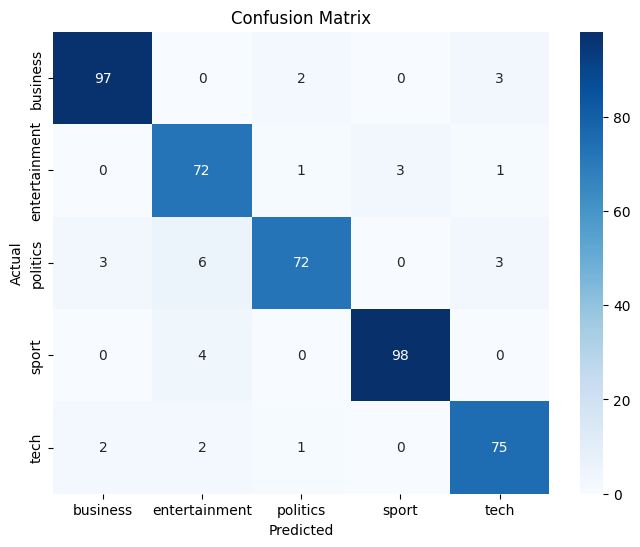

In [90]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

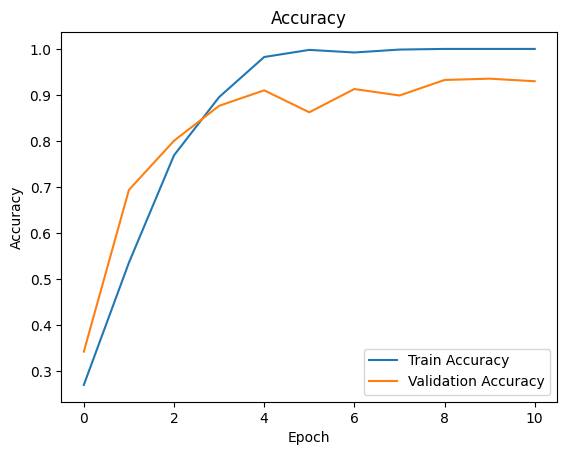

In [91]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

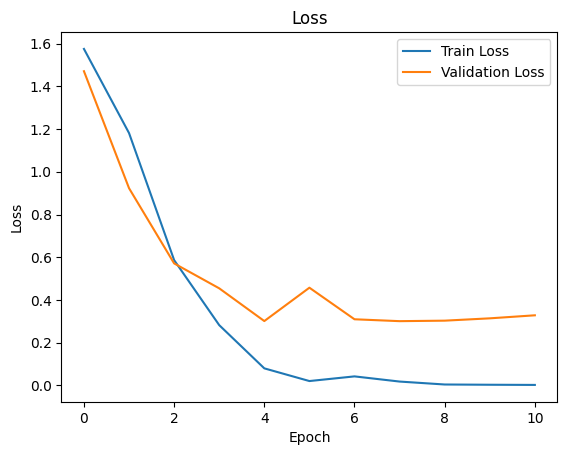

In [92]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

## Test de prédiction sur un nouvel article

Après l’évaluation quantitative du modèle, nous testons sa capacité à généraliser sur un article écrit manuellement ou récupéré en dehors du dataset.

L’objectif est de simuler une utilisation réelle : donner un article brut au modèle et obtenir la catégorie prédite.

In [93]:
def predict_news_category(article):
    # Nettoyer le texte
    cleaned_article = clean_text(article)

    # Transformer le texte en séquence numérique
    sequence = tokenizer.texts_to_sequences([cleaned_article])

    # Appliquer le même padding que pendant l'entraînement
    padded_sequence = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post',
        truncating='post'
    )

    # Prédire les probabilités
    probabilities = model.predict(padded_sequence)

    # Récupérer la classe avec la probabilité maximale
    predicted_index = probabilities.argmax(axis=1)[0]

    # Convertir l'index numérique en catégorie textuelle
    predicted_category = label_encoder.inverse_transform([predicted_index])[0]

    return predicted_category, probabilities[0]

In [98]:
new_article = """
The actor received international praise for his performance in the new movie released this weekend.
Fans and critics described the film as one of the best productions of the year.
"""

predicted_category, probabilities = predict_news_category(new_article)

print("Catégorie prédite :", predicted_category)
print("Probabilités :", probabilities)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
Catégorie prédite : entertainment
Probabilités : [3.4760775e-05 9.8929566e-01 1.5605806e-04 1.0489755e-02 2.3735032e-05]


### Interprétation

Le modèle reçoit un article brut, applique les mêmes étapes que pendant l’entraînement : nettoyage, tokenization, padding, puis prédiction.

La catégorie ayant la probabilité la plus élevée est sélectionnée comme classe finale.  
Ce test permet de vérifier si le modèle peut être utilisé sur de nouveaux textes non présents dans le dataset.

# Pipeline complet de ce projet :
  - importation des donnees textes brutes.
  - tokenization .
  - padding .
  - LSTM (bidirectionnel)
  - embidding
  - (skipping the overfitting by dropout and early_stop)
  - evaluation ,confusion matrix , visualisation of train and validation accuracy
  - generalisation of the model based on some new articles .